# Importing libraries

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers
import time

# Loadinf fashion-MINST dataset

In [13]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalizing data
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Flatting images into vectors for the MLP
X_train = X_train.reshape(-1, 28 * 28)
X_test = X_test.reshape(-1, 28 * 28)

num_classes = 10

# Defining a funciton for training model with different optimization functions
- one hidden layer with ReLU activation function and 128 neurons
- output layer with softmax activation function

In [14]:
def create_model(optimizer):
    model = keras.Sequential([layers.Dense(43, activation='relu', input_shape=(784,)),layers.Dense(num_classes, activation='softmax')])
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


# Using ADAM optimizer
- training model for 100 epochs
- batch size 128

In [15]:
optimizer_adam = optimizers.Adam(learning_rate=0.0001)
model_adam = create_model(optimizer_adam)

# Training the model
start_time = time.time()
history_adam = model_adam.fit(X_train, y_train, epochs=100, batch_size=128, validation_data=(X_test, y_test),verbose=1)
end_time = time.time()
training_time_adam = end_time - start_time
print(f"Training time with Adam optimizer: {training_time_adam:.2f} seconds")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4619 - loss: 1.5803 - val_accuracy: 0.7337 - val_loss: 0.8052
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7594 - loss: 0.7397 - val_accuracy: 0.7769 - val_loss: 0.6533
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7976 - loss: 0.6095 - val_accuracy: 0.8021 - val_loss: 0.5887
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8161 - loss: 0.5577 - val_accuracy: 0.8116 - val_loss: 0.5525
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8265 - loss: 0.5219 - val_accuracy: 0.8226 - val_loss: 0.5268
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8359 - loss: 0.4930 - val_accuracy: 0.8272 - val_loss: 0.5093
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8382 - loss: 0.4804 - val_accuracy: 0.8290 - val_loss: 0.4967
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8447 - loss: 0.4630 - val_accu

# Using NADAM optimization function
- 100 epochs
- batch size 128


In [16]:
optimizer_nadam = optimizers.Nadam()
model_nadam = create_model(optimizer_nadam)

# Training the model
start_time = time.time()
history_nadam = model_nadam.fit(X_train, y_train, epochs=100, batch_size=128, validation_data=(X_test, y_test), verbose=1)
end_time = time.time()
training_time_nadam = end_time - start_time
print(f"Training time with Nadam optimizer: {training_time_nadam:.2f} seconds")


Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7056 - loss: 0.8702 - val_accuracy: 0.8297 - val_loss: 0.4937
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8492 - loss: 0.4393 - val_accuracy: 0.8456 - val_loss: 0.4408
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8612 - loss: 0.3993 - val_accuracy: 0.8490 - val_loss: 0.4290
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8662 - loss: 0.3825 - val_accuracy: 0.8605 - val_loss: 0.4057
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8726 - loss: 0.3618 - val_accuracy: 0.8601 - val_loss: 0.3951
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8768 - loss: 0.3431 - val_accuracy: 0.8627 - val_loss: 0.3892
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8802 - loss: 0.3348 - val_accuracy: 0.8648 - val_loss: 0.3825
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8854 - loss: 0.3219 - val_accu

# Using RMSprop optimization funcction


In [17]:
optimizer_rmsprop = optimizers.RMSprop()
model_rmsprop = create_model(optimizer_rmsprop)

# Training the model
start_time = time.time()
history_rmsprop = model_rmsprop.fit(X_train, y_train, epochs=100, batch_size=128, validation_data=(X_test, y_test),verbose=1)
end_time = time.time()
training_time_rmsprop = end_time - start_time
print(f"Training time with RMSprop optimizer: {training_time_rmsprop:.2f} seconds")


Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7201 - loss: 0.8513 - val_accuracy: 0.8062 - val_loss: 0.5459
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8373 - loss: 0.4682 - val_accuracy: 0.8461 - val_loss: 0.4478
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8537 - loss: 0.4144 - val_accuracy: 0.8408 - val_loss: 0.4428
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8642 - loss: 0.3876 - val_accuracy: 0.8479 - val_loss: 0.4306
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8682 - loss: 0.3682 - val_accuracy: 0.8318 - val_loss: 0.4576
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8741 - loss: 0.3545 - val_accuracy: 0.8565 - val_loss: 0.4083
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8792 - loss: 0.3449 - val_accuracy: 0.8663 - val_loss: 0.3797
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8807 - loss: 0.3331 - val_accu

# Visualizing results

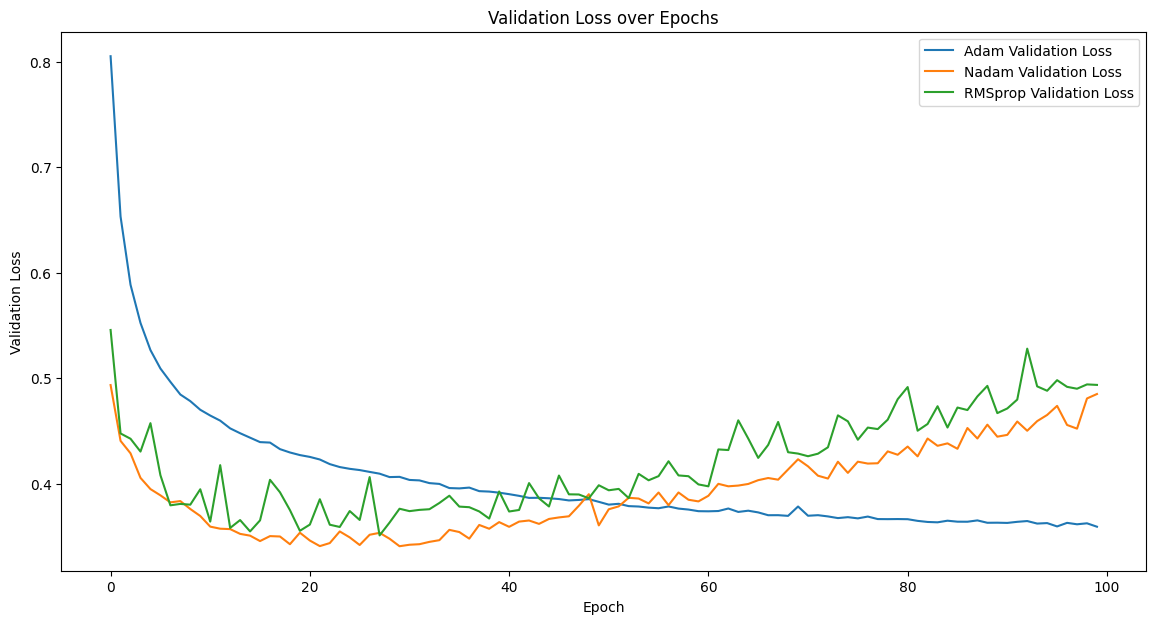

In [18]:
# Plot training and validation loss
plt.figure(figsize=(14, 7))

# Adam
plt.plot(history_adam.history['val_loss'], label='Adam Validation Loss')

# Nadam
plt.plot(history_nadam.history['val_loss'], label='Nadam Validation Loss')

# RMSprop
plt.plot(history_rmsprop.history['val_loss'], label='RMSprop Validation Loss')

plt.title('Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()


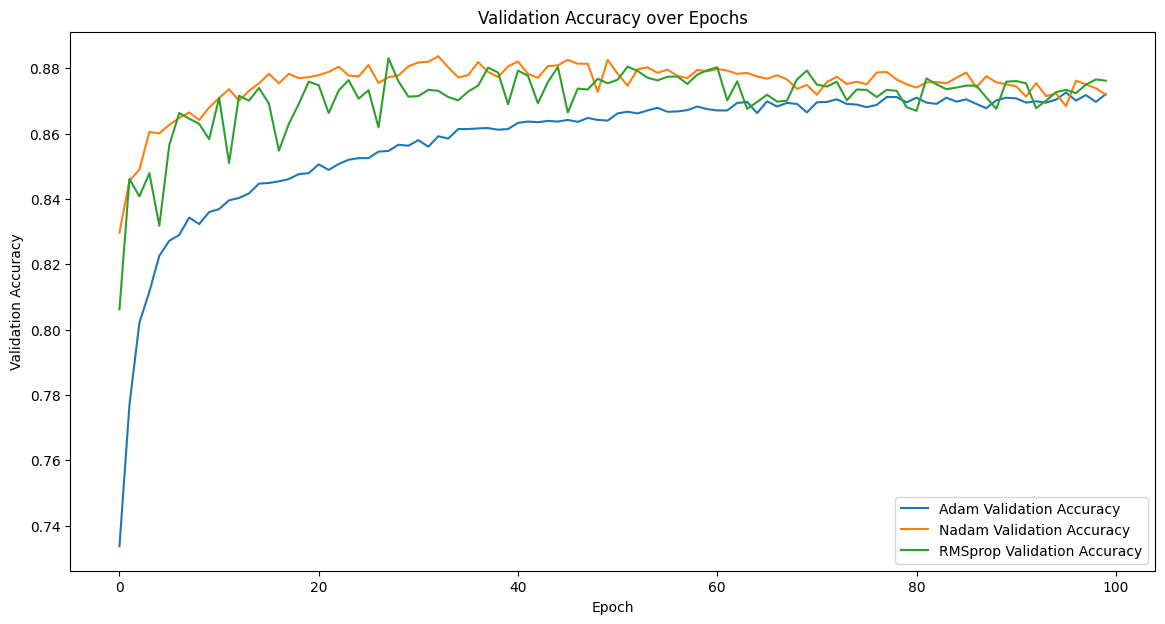

In [19]:
# Plot training and validation accuracy
plt.figure(figsize=(14, 7))

# Adam
plt.plot(history_adam.history['val_accuracy'], label='Adam Validation Accuracy')

# Nadam
plt.plot(history_nadam.history['val_accuracy'], label='Nadam Validation Accuracy')

# RMSprop
plt.plot(history_rmsprop.history['val_accuracy'], label='RMSprop Validation Accuracy')

plt.title('Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()


# Can bayesian search improve the process

- definition
  - bayesian search is a probabilistic model based algorithm to optimize the hyperparameters
- advantage
  - reduces the evaluations comparing to grid or random search
- improving the process
  - Using Bayesian optimization can help find better hyperparameter configurations that improve convergence speed and model accuracy.
  It can automate the hyperparameter tuning process, saving time and computational resources.

# implementing the bayesian search

In [20]:
!pip install hyperopt

# Importing libraries
from hyperopt import Trials, STATUS_OK, tpe, fmin, hp
from hyperopt import space_eval
from tensorflow.keras.backend import clear_session

# objective function
def objective(params):
    clear_session()
    model = keras.Sequential([layers.Dense(int(params['units']), activation='relu', input_shape=(784,)),layers.Dense(num_classes, activation='softmax')])
    optimizer_choice = params['optimizer']
    model.compile(optimizer=optimizer_choice,loss='sparse_categorical_crossentropy',metrics=['accuracy'])
    history = model.fit(X_train, y_train,epochs=20,batch_size=int(params['batch_size']),validation_split=0.1,verbose=0)
    val_acc = history.history['val_accuracy'][-1]
    return {'loss': -val_acc, 'status': STATUS_OK}

# search space
space = {'units': hp.quniform('units', 64, 256, 32),'batch_size': hp.quniform('batch_size', 64, 256, 64),'optimizer': hp.choice('optimizer', ['adam', 'nadam', 'rmsprop'])}

# bayesian optimization
trials = Trials()
best = fmin(fn=objective,space=space,algo=tpe.suggest,max_evals=10,trials=trials)

# best hyperparameters
best_params = space_eval(space, best)
print("Best hyperparameters:", best_params)


100%|██████████| 10/10 [10:51<00:00, 65.12s/trial, best loss: -0.8953333497047424]
Best hyperparameters: {'batch_size': 64.0, 'optimizer': 'adam', 'units': 192.0}


In [24]:
def create_model(optimizer):
    model = keras.Sequential([layers.Dense(192, activation='relu', input_shape=(784,)),layers.Dense(num_classes, activation='softmax')])
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

optimizer_adam = optimizers.Adam(learning_rate=0.0001)
model_searched = create_model(optimizer_adam)

# Training the model
start_time = time.time()
history_searched = model_searched.fit(X_train, y_train, epochs=100, batch_size=64, validation_data=(X_test, y_test),verbose=1)
end_time = time.time()
training_time_adam = end_time - start_time
print(f"Training time with Adam optimizer: {training_time_adam:.2f} seconds")




Epoch 1/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6693 - loss: 1.0615 - val_accuracy: 0.8151 - val_loss: 0.5568
Epoch 2/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8318 - loss: 0.5063 - val_accuracy: 0.8305 - val_loss: 0.4889
Epoch 3/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8473 - loss: 0.4508 - val_accuracy: 0.8398 - val_loss: 0.4540
Epoch 4/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8557 - loss: 0.4180 - val_accuracy: 0.8474 - val_loss: 0.4355
Epoch 5/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8638 - loss: 0.3940 - val_accuracy: 0.8444 - val_loss: 0.4383
Epoch 6/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8687 - loss: 0.3813 - val_accuracy: 0.8566 - val_loss: 0.4102
Epoch 7/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8720 - loss: 0.3725 - val_accuracy: 0.8584 - val_loss: 0.4023
Epoch 8/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8770 - loss: 0.3532 - val_accu

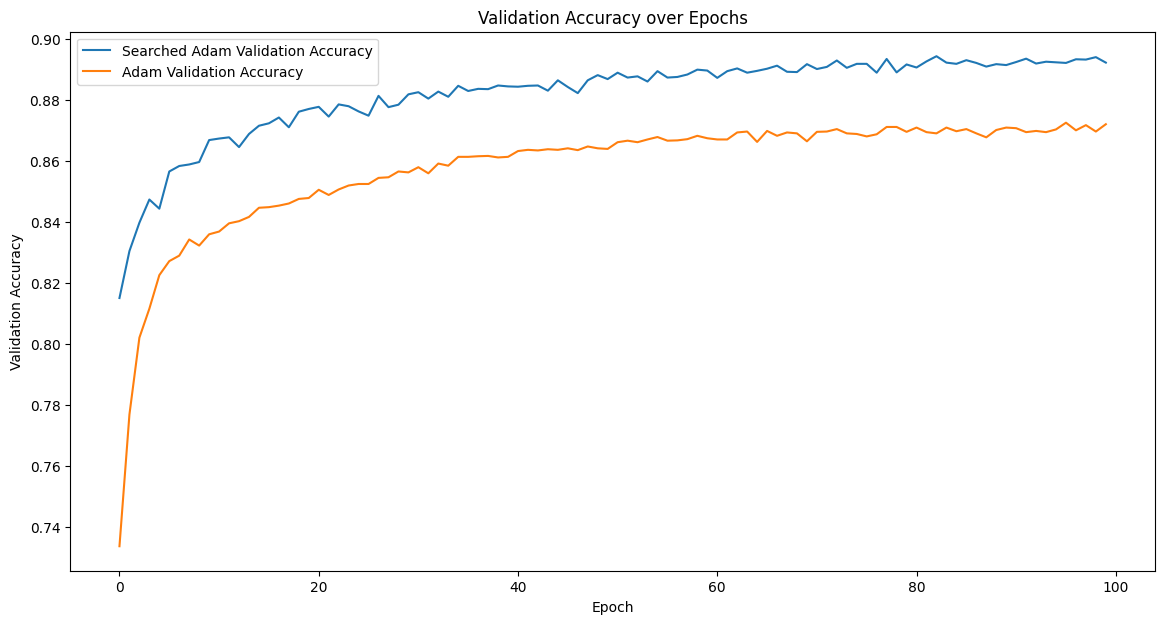

In [25]:
# Plot training and validation accuracy
plt.figure(figsize=(14, 7))

# Adam
plt.plot(history_searched.history['val_accuracy'], label='Searched Adam Validation Accuracy')

plt.plot(history_adam.history['val_accuracy'], label='Adam Validation Accuracy')


plt.title('Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

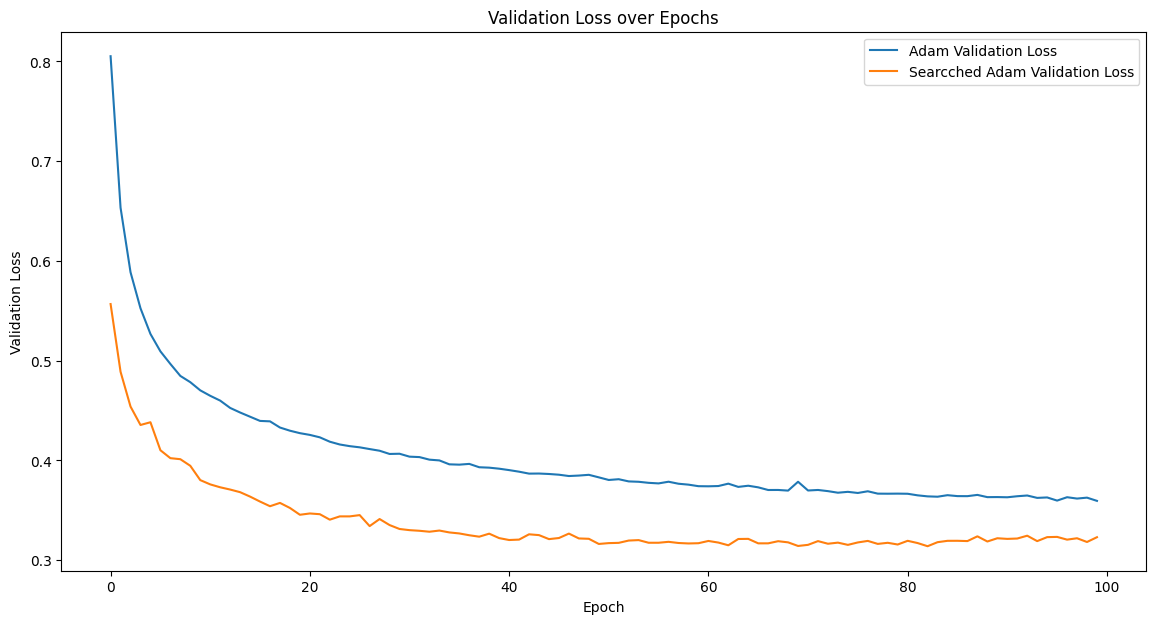

In [26]:
# Plot training and validation loss
plt.figure(figsize=(14, 7))

# Adam
plt.plot(history_adam.history['val_loss'], label='Adam Validation Loss')

plt.plot(history_searched.history['val_loss'], label='Searcched Adam Validation Loss')

plt.title('Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()